# SSVEP Signal Classification with FFT, CCA and FBCCA

This project explores target classification in an SSVEP-based brain-computer interface using EEG recordings.

The goal is to compare several frequency-recognition approaches and evaluate how decision window length affects classification accuracy.

## Project Goals

- Implement and compare FFT-based frequency detection, CCA and FBCCA.
- Evaluate classification accuracy for different decision window sizes from 0.5 to 5.0 seconds.
- Apply ICA-based artifact removal to reduce eye-movement artifacts.
- Analyze individual and group-level classification performance.
- Visualize accuracy trends and confusion matrices across methods.

## Key Methods

- EEG preprocessing
- Frequency-domain analysis
- Fast Fourier Transform
- Canonical Correlation Analysis
- Filter Bank CCA
- Independent Component Analysis
- Accuracy evaluation and confusion matrix analysis

In [1]:
# %pip install -U mne

In [2]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import scipy.io
from scipy import signal

import mne
from mne.preprocessing import ICA

from tqdm.auto import tqdm
from joblib import Parallel, delayed

import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = Path("./data")

## Dataset and Metadata

The dataset contains EEG recordings with the `data` matrix shaped as **(64 channels, 1500 samples, 40 target frequencies, 6 trials)**.

The sampling rate is **250 Hz**, and each epoch has a duration of **6 seconds**, including approximately 0.5 seconds before stimulus onset.

In [3]:
# Метаданные: частоты/фазы + список каналов
ff = scipy.io.loadmat(DATA_PATH / "Freq_Phase.mat")
freqs_all = ff["freqs"].ravel()   # 40 частот
phases_all = ff["phases"].ravel() if "phases" in ff else None

# Монтаж и имена каналов
montage = mne.channels.read_custom_montage(DATA_PATH / "64-channels.loc")
ch_names = montage.ch_names

SFREQ = 250.0
N_CH = len(ch_names)

TARGET_IDXS = np.array([0,1,2,3,4,5,6,7,16,17,18,19,20,21,22,23], dtype=int)
target_freqs = freqs_all[TARGET_IDXS]

print("Всего частот:", len(freqs_all), " | целевых:", len(target_freqs))
print("Целевые частоты (Гц):", np.round(target_freqs, 3))


Всего частот: 40  | целевых: 16
Целевые частоты (Гц): [ 8.   9.  10.  11.  12.  13.  14.  15.   8.4  9.4 10.4 11.4 12.4 13.4
 14.4 15.4]


### Data Loading and Epoch Extraction

This section defines a unified loader for `S{i}.mat` files and a function for extracting a decision window of length `win_sec` from each 6-second EEG epoch.

In [4]:
def load_subject_mat(subject_id: int):
    fn = DATA_PATH / f"S{subject_id}.mat"
    mat = scipy.io.loadmat(fn)
    data = mat["data"]  #(64, 1500, 40, 6)
    # ->(6, 40, 1500, 64)
    data = np.transpose(data, (3, 2, 1, 0)).astype(np.float64)
    return data

def extract_window(epoch_tc: np.ndarray, win_sec: float, start_sec: float = 0.5) -> np.ndarray:
    if epoch_tc.shape[0] == N_CH and epoch_tc.shape[1] != N_CH:
        epoch_tc = epoch_tc.T
    n = epoch_tc.shape[0]
    start = int(round(start_sec * SFREQ))
    length = int(round(win_sec * SFREQ))
    end = min(start + length, n)
    assert end > start, "Окно нулевой длины — проверьте win_sec/start_sec."
    return epoch_tc[start:end, :]

_s1 = load_subject_mat(1)
print("S1 shape:", _s1.shape, "(trials, freqs, times, ch)")


S1 shape: (6, 40, 1500, 64) (trials, freqs, times, ch)


## Preprocessing and Channel Selection

For SSVEP classification, occipital and parietal channels are typically the most informative because they capture visual cortex activity.

This section defines candidate EEG channels and selects only those available in the dataset.

In [5]:
# Кандидаты затылочно-теменных каналов (можете расширять/сужать)
OCC_CHANNELS_CANDIDATES = [
    "Oz","O1","O2","Iz",
    "POz","PO3","PO4","PO7","PO8",
    "Pz","P1","P2","P3","P4",
    "CPz","CP1","CP2",
]

picks = [ch for ch in OCC_CHANNELS_CANDIDATES if ch in ch_names]
if len(picks) < 4:
    # Фолбэк: берем последние 16 каналов, если имена неожиданно не совпали
    picks = ch_names[-16:]

pick_idx = np.array([ch_names.index(ch) for ch in picks], dtype=int)
print("Используемые каналы (N=%d):" % len(picks), picks)

def bandpass(data_tc: np.ndarray, l_freq: float, h_freq: float):
    sos = signal.butter(4, [l_freq, h_freq], btype="bandpass", fs=SFREQ, output="sos")
    return signal.sosfiltfilt(sos, data_tc, axis=0)

def notch_50(data_tc: np.ndarray) -> np.ndarray:
    # если в ваших данных выраженная сетевая помеха на 50 Гц — включите
    b, a = signal.iirnotch(w0=50.0, Q=30.0, fs=SFREQ)
    return signal.filtfilt(b, a, data_tc, axis=0)


Используемые каналы (N=14): ['Oz', 'O1', 'O2', 'POz', 'PO3', 'PO4', 'PO7', 'PO8', 'P1', 'P2', 'P3', 'P4', 'CP1', 'CP2']


## Canonical Correlation Analysis

Standard CCA can be unstable for short decision windows and noisy EEG signals. To improve numerical stability, this implementation uses **regularized CCA**:

- compute covariance matrices `Cxx` and `Cyy`;
- add `reg * I` for regularization;
- compute singular values of the whitened matrix `Cxx^{-1/2} Cxy Cyy^{-1/2}`;
- use the **first canonical correlation** as the classification score

In [6]:
def _invsqrtm_sym(A: np.ndarray, eps: float = 1e-12):
    # A симметричная, положительно определенная
    w, V = np.linalg.eigh(A)
    w = np.maximum(w, eps)
    return (V * (1.0 / np.sqrt(w))) @ V.T

def cca_max_corr(X: np.ndarray, Y: np.ndarray, reg: float = 1e-3) -> float:
    X = X - X.mean(axis=0, keepdims=True)
    Y = Y - Y.mean(axis=0, keepdims=True)
    n = X.shape[0]
    # ковариации
    Cxx = (X.T @ X) / (n - 1) + reg * np.eye(X.shape[1])
    Cyy = (Y.T @ Y) / (n - 1) + reg * np.eye(Y.shape[1])
    Cxy = (X.T @ Y) / (n - 1)

    Wx = _invsqrtm_sym(Cxx)
    Wy = _invsqrtm_sym(Cyy)
    M = Wx @ Cxy @ Wy

    # Сингулярные значения = канонические корреляции
    s = np.linalg.svd(M, compute_uv=False)
    return float(np.clip(s[0], 0.0, 1.0))

def make_reference_signals(freq_hz: float, win_len: int, n_harm: int = 5, phase: float = 0.0) -> np.ndarray:
    t = np.arange(win_len) / SFREQ
    refs = []
    for h in range(1, n_harm + 1):
        omega = 2*np.pi*h*freq_hz
        refs.append(np.sin(omega*t + phase))
        refs.append(np.cos(omega*t + phase))
    return np.stack(refs, axis=1)

_ref = make_reference_signals(target_freqs[0], win_len=int(1.0*SFREQ), n_harm=5)
print("Reference shape:", _ref.shape)


Reference shape: (250, 10)


## FFT-Based Frequency Detection

The FFT-based approach estimates the signal spectrum within a decision window.

For each target frequency, the score is computed as the sum of spectral amplitudes at the stimulation frequency and its harmonics

In [7]:
def fft_score(epoch_tc: np.ndarray, freq_hz: float, n_harm: int = 3):
    X = epoch_tc - epoch_tc.mean(axis=0, keepdims=True)
    n = X.shape[0]
    win = np.hanning(n)[:, None]
    Xw = X * win

    # Реальный FFT
    F = np.fft.rfft(Xw, axis=0)
    freqs = np.fft.rfftfreq(n, d=1.0/SFREQ)

    # амплитуда усредненная по каналам
    amp = np.abs(F).mean(axis=1)

    score = 0.0
    for h in range(1, n_harm+1):
        f = h*freq_hz
        k = int(np.argmin(np.abs(freqs - f)))
        score += amp[k]
    return float(score)

def predict_fft(epoch_tc: np.ndarray, cand_freqs: np.ndarray, n_harm: int = 3) -> int:
    scores = [fft_score(epoch_tc, f, n_harm=n_harm) for f in cand_freqs]
    return int(np.argmax(scores))


## Filter Bank Canonical Correlation Analysis

FBCCA combines filter-bank preprocessing with CCA-based frequency recognition:

1. filter the EEG window into several frequency sub-bands;
2. compute the CCA score for each sub-band;
3. combine sub-band scores using predefined weights.

This implementation uses 5 sub-bands and weighted score aggregation.

In [8]:
@dataclass
class FilterBankSpec:
    passbands: List[Tuple[float, float]] 
    weights: np.ndarray 

def default_filterbank() -> FilterBankSpec:
    passbands = [(6, 90), (14, 90), (22, 90), (30, 90), (38, 90)]
    a, b = 1.25, 0.25
    m = np.arange(1, len(passbands)+1)
    weights = (m**(-a)) + b
    return FilterBankSpec(passbands=passbands, weights=weights)

FB = default_filterbank()

def fbcca_score(epoch_tc: np.ndarray,
                freq_hz: float,
                n_harm: int = 5,
                reg: float = 1e-3,
                fb: FilterBankSpec = FB) -> float:
    n = epoch_tc.shape[0]
    ref = make_reference_signals(freq_hz, win_len=n, n_harm=n_harm)

    scores = []
    for (l, h) in fb.passbands:
        Xf = bandpass(epoch_tc, l, min(h, SFREQ/2 - 1.0))
        rho = cca_max_corr(Xf, ref, reg=reg)
        scores.append(rho)

    scores = np.array(scores)
    return float(np.sum(fb.weights * (scores**2)))

def predict_cca(epoch_tc: np.ndarray, cand_freqs: np.ndarray, n_harm: int = 5, reg: float = 1e-3) -> int:
    n = epoch_tc.shape[0]
    scores = []
    for f in cand_freqs:
        ref = make_reference_signals(f, win_len=n, n_harm=n_harm)
        scores.append(cca_max_corr(epoch_tc, ref, reg=reg))
    return int(np.argmax(scores))

def predict_fbcca(epoch_tc: np.ndarray, cand_freqs: np.ndarray, n_harm: int = 5, reg: float = 1e-3) -> int:
    scores = [fbcca_score(epoch_tc, f, n_harm=n_harm, reg=reg) for f in cand_freqs]
    return int(np.argmax(scores))


## Evaluation: Accuracy vs. Decision Window Length

Classification performance is measured using **accuracy**

The evaluation is performed on 16 selected target frequencies using all available trials, with 6 trials per frequency.

In [9]:
def iterate_epochs(subj_data: np.ndarray, target_idxs: np.ndarray = TARGET_IDXS):
    """
    subj_data: (6, 40, 1500, 64)
    yield (epoch_tc, true_label) где true_label в [0..len(target_idxs)-1]
    """
    for rep in range(subj_data.shape[0]):
        for j, f_idx in enumerate(target_idxs):
            epoch = subj_data[rep, f_idx, :, :] 
            yield epoch, j

def compute_accuracy_for_window(subj_data: np.ndarray,
                                win_sec: float,
                                start_sec: float = 0.5,
                                use_picks: bool = True,
                                algo: str = "cca",
                                cca_n_harm: int = 5,
                                fbcca_n_harm: int = 5,
                                reg: float = 1e-3,
                                fft_n_harm: int = 3,
                                prefilter: Optional[Tuple[float,float]] = (6, 80),
                                ) -> float:

    y_true, y_pred = [], []
    for epoch, y in iterate_epochs(subj_data, TARGET_IDXS):
        X = epoch  # (time, ch)
        if use_picks:
            X = X[:, pick_idx]
        Xw = extract_window(X, win_sec=win_sec, start_sec=start_sec)

        if prefilter is not None and algo.lower() != "fbcca":
            Xw = bandpass(Xw, prefilter[0], prefilter[1])

        if algo.lower() == "fft":
            pred = predict_fft(Xw, target_freqs, n_harm=fft_n_harm)
        elif algo.lower() == "cca":
            pred = predict_cca(Xw, target_freqs, n_harm=cca_n_harm, reg=reg)
        elif algo.lower() == "fbcca":
            pred = predict_fbcca(Xw, target_freqs, n_harm=fbcca_n_harm, reg=reg)
        else:
            raise ValueError("algo must be one of: fft, cca, fbcca")

        y_true.append(y)
        y_pred.append(pred)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return float((y_true == y_pred).mean())

# проверка на одном субъекте 
s1 = load_subject_mat(1)
for a in ["fft","cca","fbcca"]:
    acc = compute_accuracy_for_window(s1, win_sec=1.0, algo=a)
    print(a, "acc@1s =", round(acc, 3))


fft acc@1s = 0.24
cca acc@1s = 0.25
fbcca acc@1s = 0.562


### Evaluation Across Subjects and Window Sizes

Decision windows are evaluated from 0.5 to 5.0 seconds with a step of 0.5 seconds.

In [10]:
WINDOWS = np.round(np.arange(0.5, 5.0+1e-9, 0.5), 2)
SUBJECT_IDS = list(range(1, 36))

def eval_subject(subject_id: int, windows=WINDOWS, algos=("fft","cca","fbcca")) -> pd.DataFrame:
    subj = load_subject_mat(subject_id)
    rows = []
    for w in windows:
        for algo in algos:
            acc = compute_accuracy_for_window(subj, win_sec=float(w), algo=algo)
            rows.append({"subject": subject_id, "window_sec": float(w), "algo": algo, "accuracy": acc})
    return pd.DataFrame(rows)

# параллелим по людям
N_JOBS = max(1, (os.cpu_count() or 2) - 1)

results_path = Path("./results_raw.csv")
if results_path.exists():
    results_raw = pd.read_csv(results_path)
    print("Загружены сохраненные результаты:", results_path)
else:
    dfs = Parallel(n_jobs=N_JOBS)(
        delayed(eval_subject)(sid) for sid in tqdm(SUBJECT_IDS, desc="Subjects")
    )
    results_raw = pd.concat(dfs, ignore_index=True)
    results_raw.to_csv(results_path, index=False)
    print("Сохранено:", results_path)

results_raw.head()


Загружены сохранённые результаты: results_raw.csv


,subject,window_sec,algo,accuracy
0,1,0.5,fft,0.135417
1,1,0.5,cca,0.125000
2,1,0.5,fbcca,0.197917
3,1,1.0,fft,0.239583
4,1,1.0,cca,0.250000


## Subject-Level Accuracy Curves

The x-axis represents decision window length, and the y-axis represents classification accuracy.

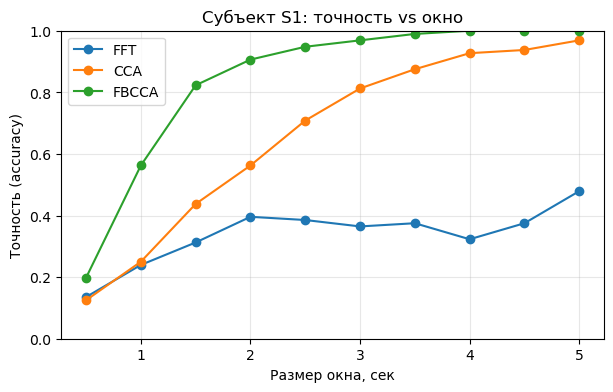

In [11]:
def plot_subject_curves(results: pd.DataFrame, subject_id: int):
    df = results[results["subject"] == subject_id].copy()
    plt.figure(figsize=(7,4))
    for algo in ["fft","cca","fbcca"]:
        d = df[df["algo"]==algo].sort_values("window_sec")
        plt.plot(d["window_sec"], d["accuracy"], marker="o", label=algo.upper())
    plt.ylim(0,1.0)
    plt.xlabel("Размер окна, сек")
    plt.ylabel("Точность (accuracy)")
    plt.title(f"Субъект S{subject_id}: точность vs окно")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

plot_subject_curves(results_raw, subject_id=1)


## ICA-Based Eye Artifact Removal

ICA is applied to reduce eye-movement artifacts in the EEG signal.

The preprocessing pipeline includes:

1. creating an `mne.EpochsArray` from all subject epochs;
2. filtering the signal in the 1–45 Hz range before ICA;
3. fitting ICA using the FastICA algorithm;
4. selecting artifact-related components by correlating them with a virtual EOG signal computed from frontal channels;
5. excluding components with high absolute correlation and artifact-like spatial or temporal patterns;
6. applying ICA and comparing signal quality, PSD and classification accuracy before and after preprocessing.

Исключённые компоненты ICA: [0, 1]
Corrs (первые 10): [ 0.761  0.448  0.263 -0.227 -0.017  0.038 -0.108 -0.002 -0.102 -0.251]


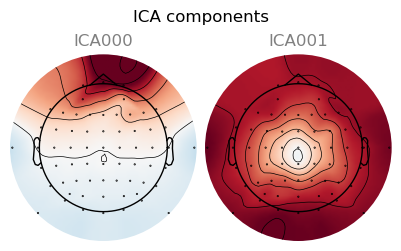

    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
240 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
240 matching events found
No baseline correction applied
0 projection items activated


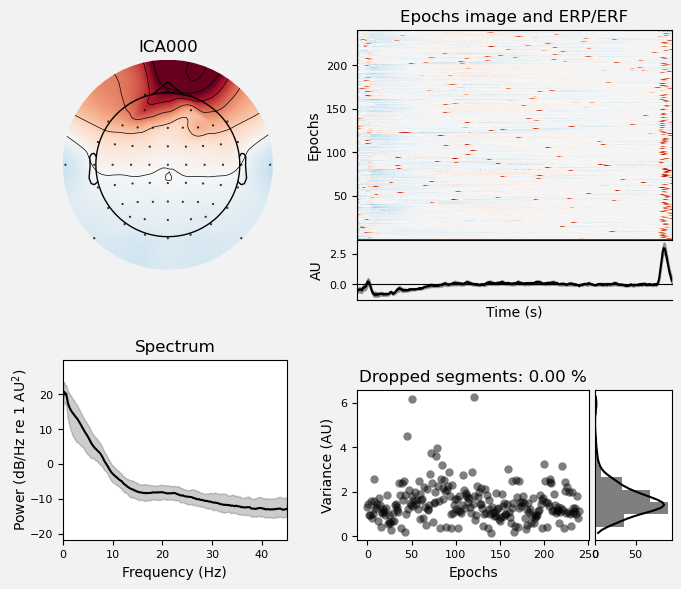

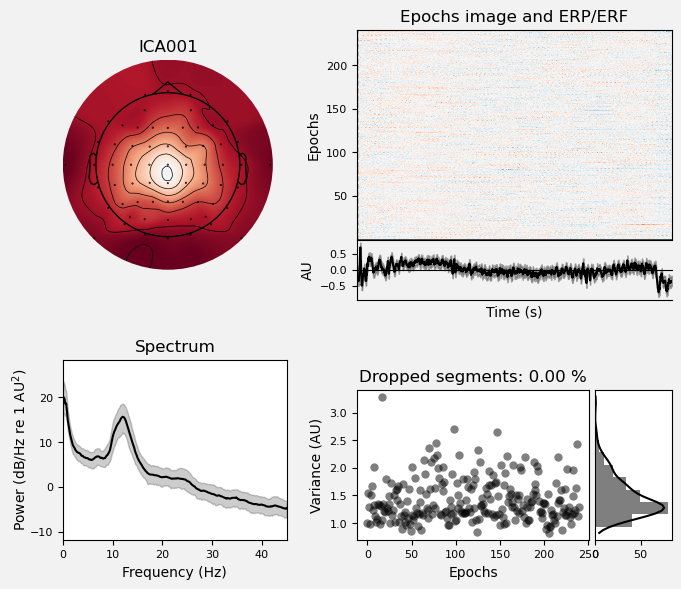

In [12]:
FRONTAL_CAND = ["Fp1","Fp2","AF7","AF8","F7","F8","F3","F4","Fz"]

def build_epochs_for_ica(subj_data: np.ndarray, tmin: float = 0.0):
    # Берем все 40*6=240 эпох
    epochs_list = []
    for rep in range(subj_data.shape[0]):
        for f in range(subj_data.shape[1]):
            epoch = subj_data[rep, f, :, :].T  # (ch, time)
            epochs_list.append(epoch)
    epochs_arr = np.stack(epochs_list, axis=0)
    info = mne.create_info(ch_names=ch_names, sfreq=SFREQ, ch_types="eeg")
    info.set_montage(montage)
    epochs = mne.EpochsArray(epochs_arr, info, tmin=tmin, verbose=False)
    return epochs

def fit_ica_and_clean(subj_data: np.ndarray,
                      n_components: float = 0.99,
                      corr_thr: float = 0.3,
                      random_state: int = RANDOM_STATE):
    epochs = build_epochs_for_ica(subj_data, tmin=0.0)
    epochs_f = epochs.copy().filter(1.0, 45.0, verbose=False)

    ica = ICA(n_components=n_components, random_state=random_state, method="fastica", max_iter="auto")
    ica.fit(epochs_f, verbose=False)

    frontal = [ch for ch in FRONTAL_CAND if ch in ch_names]
    if len(frontal) == 0:
        raise RuntimeError("Не найдено фронтальных каналов для поиска глазных артефактов.")

    frontal_data = epochs_f.copy().pick(frontal).get_data()  # (n_epochs, n_ch, n_times)
    vEOG = frontal_data.mean(axis=1)  # (n_epochs, n_times)
    vEOG_1d = vEOG.reshape(vEOG.shape[0], -1)

    sources = ica.get_sources(epochs_f).get_data()  # (n_epochs, n_comp, n_times)
    n_comp = sources.shape[1]
    src_1d = sources.reshape(sources.shape[0], n_comp, -1)

    corrs = []
    ve = vEOG_1d.ravel()
    ve = (ve - ve.mean()) / (ve.std() + 1e-12)
    for k in range(n_comp):
        s = src_1d[:, k, :].ravel()
        s = (s - s.mean()) / (s.std() + 1e-12)
        corrs.append(float(np.corrcoef(s, ve)[0,1]))
    corrs = np.array(corrs)

    bads = np.where(np.abs(corrs) >= corr_thr)[0].tolist()
    ica.exclude = bads

    epochs_clean = epochs.copy()
    ica.apply(epochs_clean, verbose=False)

    return ica, epochs, epochs_clean, bads, corrs

# Демонстрация на одном субъекте
subj_id_demo = 1
subj_demo = load_subject_mat(subj_id_demo)

ica, ep_before, ep_after, bads, corrs = fit_ica_and_clean(subj_demo, corr_thr=0.3)
print("Исключенные компоненты ICA:", bads)
print("Corrs (первые 10):", np.round(corrs[:10], 3))

# Визуальная проверка: топографии и временные ряды для исключенных компонент
if len(bads) > 0:
    ica.plot_components(picks=bads);
    ica.plot_properties(ep_before, picks=bads, psd_args={"fmax": 45});


### Signal and Spectrum Comparison Before and After ICA

This section visualizes the effect of ICA on a selected EEG epoch.

The comparison includes overlays for one frontal channel, one occipital channel and the corresponding power spectral density.

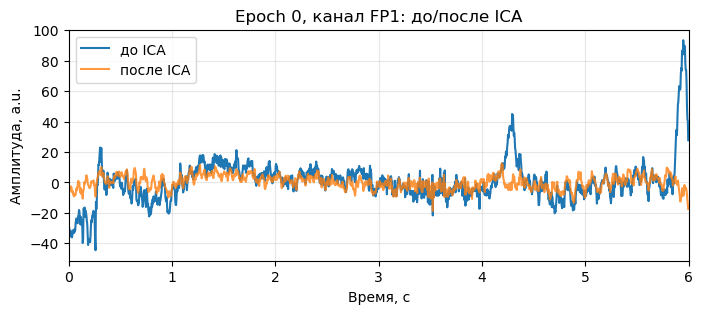

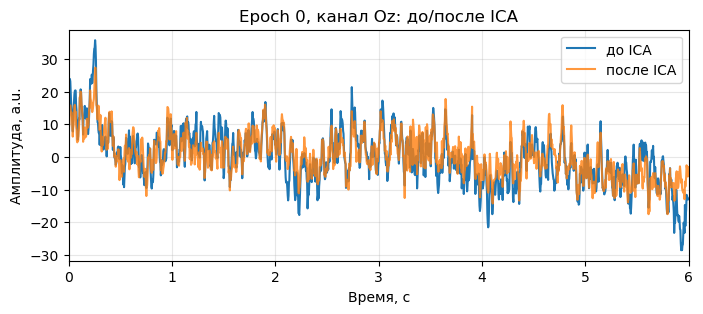

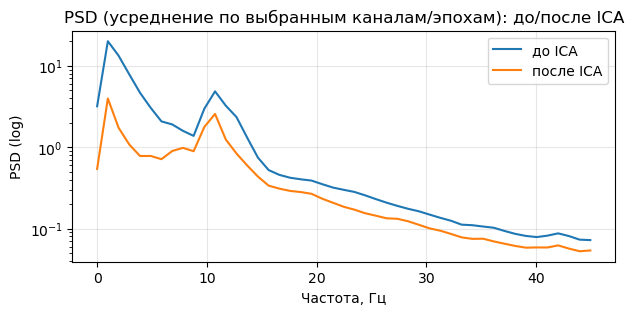

In [13]:
def compare_before_after(ep_before: mne.EpochsArray,
                         ep_after: mne.EpochsArray,
                         ch: str,
                         epoch_idx: int = 0,
                         tmax: float = 6.0):
    x1 = ep_before.copy().pick([ch]).get_data()[epoch_idx, 0, :]
    x2 = ep_after.copy().pick([ch]).get_data()[epoch_idx, 0, :]
    t = ep_before.times

    plt.figure(figsize=(8,3))
    plt.plot(t, x1, label="до ICA")
    plt.plot(t, x2, label="после ICA", alpha=0.8)
    plt.xlim(0, tmax)
    plt.xlabel("Время, с")
    plt.ylabel("Амплитуда, a.u.")
    plt.title(f"Epoch {epoch_idx}, канал {ch}: до/после ICA")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

def compare_psd(ep_before: mne.EpochsArray, ep_after: mne.EpochsArray, picks_show: List[str], fmax: float = 45.0):
    x1 = ep_before.copy().pick(picks_show).get_data()  # (n_epochs, n_ch, n_times)
    x2 = ep_after.copy().pick(picks_show).get_data()

    psd1, f = mne.time_frequency.psd_array_welch(
        x1.reshape(-1, x1.shape[-1]),
        sfreq=SFREQ, fmax=fmax, verbose=False
    )
    psd2, _ = mne.time_frequency.psd_array_welch(
        x2.reshape(-1, x2.shape[-1]),
        sfreq=SFREQ, fmax=fmax, verbose=False
    )
    psd1 = psd1.mean(axis=0)
    psd2 = psd2.mean(axis=0)

    plt.figure(figsize=(7,3))
    plt.semilogy(f, psd1, label="до ICA")
    plt.semilogy(f, psd2, label="после ICA")
    plt.xlabel("Частота, Гц")
    plt.ylabel("PSD (log)")
    plt.title("PSD (усреднение по выбранным каналам/эпохам): до/после ICA")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

front_ch = next((ch for ch in ["Fp1","Fp2","AF7","AF8","Fz"] if ch in ch_names), ch_names[0])
occ_ch   = next((ch for ch in ["Oz","O1","O2","POz"] if ch in ch_names), picks[0])

compare_before_after(ep_before=ep_before, ep_after=ep_after, ch=front_ch, epoch_idx=0)
compare_before_after(ep_before=ep_before, ep_after=ep_after, ch=occ_ch, epoch_idx=0)

compare_psd(ep_before, ep_after, picks_show=[front_ch, occ_ch], fmax=45.0)


### Classification Accuracy Before and After ICA


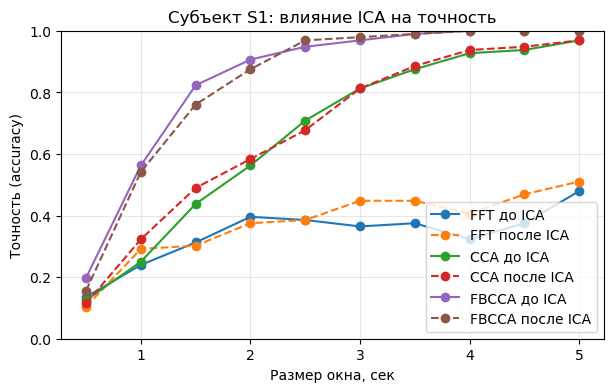

,window_sec,algo,acc_before,acc_after
0,0.5,fft,0.135417,0.104167
1,0.5,cca,0.125000,0.114583
2,0.5,fbcca,0.197917,0.156250
3,1.0,fft,0.239583,0.291667
4,1.0,cca,0.250000,0.322917
5,1.0,fbcca,0.562500,0.541667
6,1.5,fft,0.312500,0.302083
7,1.5,cca,0.437500,0.489583
8,1.5,fbcca,0.822917,0.760417
9,2.0,fft,0.395833,0.375000


In [14]:
def epochsarray_to_subject_like(ep: mne.EpochsArray):

    data = ep.get_data()
    data = np.transpose(data, (0, 2, 1))
    out = np.zeros((6, 40, data.shape[1], data.shape[2]), dtype=np.float64)
    idx = 0
    for rep in range(6):
        for f in range(40):
            out[rep, f, :, :] = data[idx]
            idx += 1
    return out

subj_clean_demo = epochsarray_to_subject_like(ep_after)

rows = []
for w in WINDOWS:
    for algo in ["fft","cca","fbcca"]:
        a0 = compute_accuracy_for_window(subj_demo, win_sec=float(w), algo=algo)
        a1 = compute_accuracy_for_window(subj_clean_demo, win_sec=float(w), algo=algo)
        rows.append({"window_sec": float(w), "algo": algo, "acc_before": a0, "acc_after": a1})
df_ica_demo = pd.DataFrame(rows)

plt.figure(figsize=(7,4))
for algo in ["fft","cca","fbcca"]:
    d = df_ica_demo[df_ica_demo["algo"]==algo].sort_values("window_sec")
    plt.plot(d["window_sec"], d["acc_before"], marker="o", label=f"{algo.upper()} до ICA")
    plt.plot(d["window_sec"], d["acc_after"], marker="o", linestyle="--", label=f"{algo.upper()} после ICA")
plt.ylim(0,1.0)
plt.xlabel("Размер окна, сек")
plt.ylabel("Точность (accuracy)")
plt.title(f"Субъект S{subj_id_demo}: влияние ICA на точность")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

df_ica_demo


## Group-Level Performance: Median and Interquartile Range (CCA vs FBCCA)


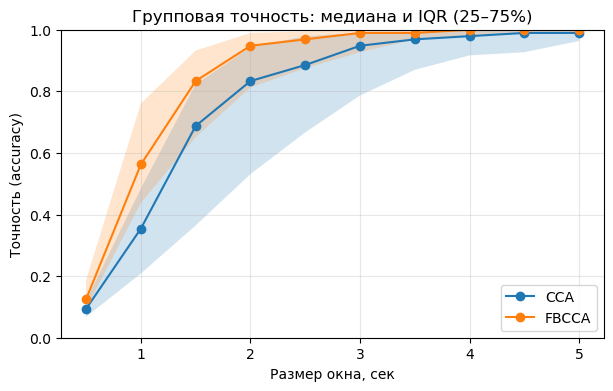

In [15]:
def plot_group_median_iqr(results: pd.DataFrame, algos=("cca","fbcca")):
    plt.figure(figsize=(7,4))
    for algo in algos:
        df = results[results["algo"]==algo].copy()
        stats = df.groupby("window_sec")["accuracy"].agg(
            median="median",
            q25=lambda x: np.quantile(x, 0.25),
            q75=lambda x: np.quantile(x, 0.75)
        ).reset_index().sort_values("window_sec")

        x = stats["window_sec"].values
        med = stats["median"].values
        q25 = stats["q25"].values
        q75 = stats["q75"].values

        plt.plot(x, med, marker="o", label=algo.upper())
        plt.fill_between(x, q25, q75, alpha=0.2)

    plt.ylim(0, 1.0)
    plt.xlabel("Размер окна, сек")
    plt.ylabel("Точность (accuracy)")
    plt.title("Групповая точность: медиана и IQR (25–75%)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

plot_group_median_iqr(results_raw, algos=("cca","fbcca"))


## Method Comparison

This section compares FFT, CCA and FBCCA using median accuracy across subjects for each decision window size.

The best-performing method is selected based on the highest median accuracy.

In [17]:
def summarize_best(results: pd.DataFrame):
    summary = (results
               .groupby(["algo","window_sec"])["accuracy"]
               .median()
               .reset_index()
               .pivot(index="window_sec", columns="algo", values="accuracy")
              )
    display(summary)

    # лучший по каждому окну
    best_per_w = summary.idxmax(axis=1)
    print("Лучший алгоритм по каждому окну:")
    for w, b in best_per_w.items():
        print(f"  {w:.1f} c -> {b}")

    # глобально по среднему по окнам
    mean_over_w = summary.mean(axis=0).sort_values(ascending=False)
    print("Средняя медианная точность по окнам:")
    print(mean_over_w)

summarize_best(results_raw)


algo,cca,fbcca,fft
window_sec,,,
0.5,0.093750,0.125000,0.093750
1.0,0.354167,0.562500,0.239583
1.5,0.687500,0.833333,0.375000
2.0,0.833333,0.947917,0.510417
2.5,0.885417,0.968750,0.583333
3.0,0.947917,0.989583,0.614583
3.5,0.968750,0.989583,0.666667
4.0,0.979167,1.000000,0.697917
4.5,0.989583,1.000000,0.760417


Лучший алгоритм по каждому окну:
  0.5 c -> fbcca
  1.0 c -> fbcca
  1.5 c -> fbcca
  2.0 c -> fbcca
  2.5 c -> fbcca
  3.0 c -> fbcca
  3.5 c -> fbcca
  4.0 c -> fbcca
  4.5 c -> fbcca
  5.0 c -> fbcca
Средняя медианная точность по окнам:
algo
fbcca    0.841667
cca      0.772917
fft      0.538542
dtype: float64


## Average Confusion Matrix Across Subjects

A confusion matrix is computed for each method at a fixed decision window length, set to 2.0 seconds by default.

The matrices are then averaged across subjects to analyze systematic frequency confusions.


CM fft:   0%|          | 0/35 [00:00<?, ?it/s]

CM cca:   0%|          | 0/35 [00:00<?, ?it/s]

CM fbcca:   0%|          | 0/35 [00:00<?, ?it/s]

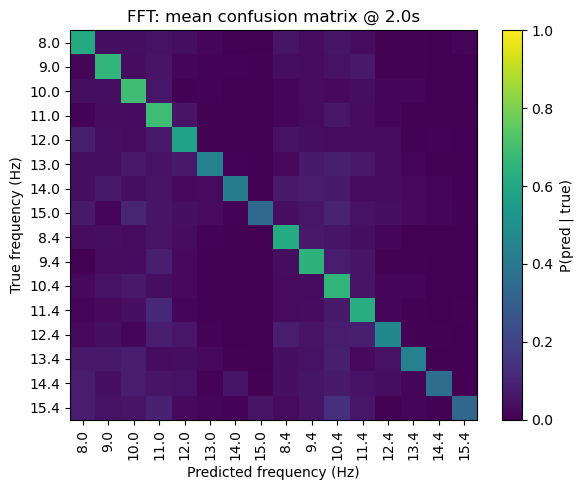

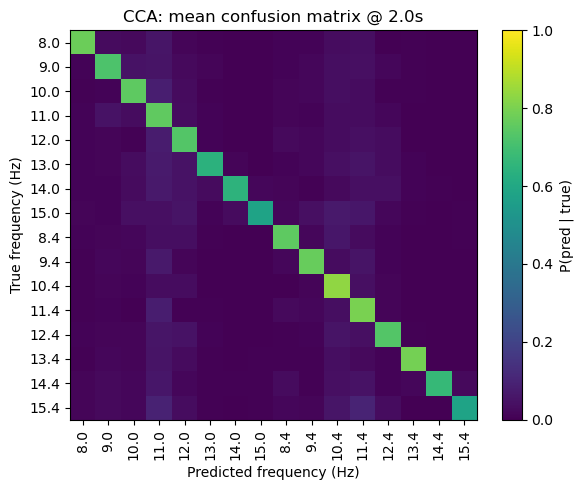

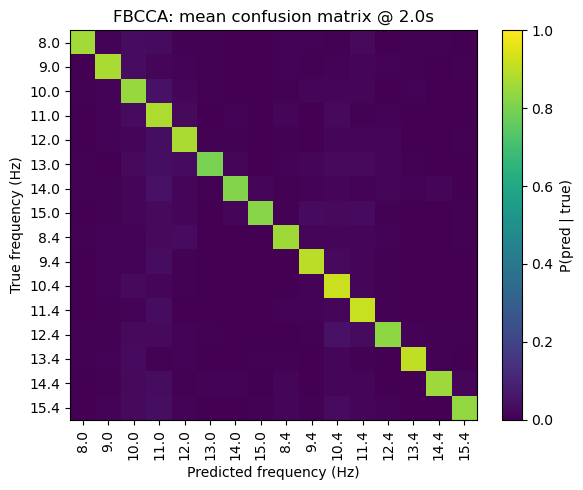

In [19]:
from sklearn.metrics import confusion_matrix

def predict_all_epochs(subj_data: np.ndarray,
                       win_sec: float,
                       algo: str,
                       start_sec: float = 0.5,
                       use_picks: bool = True):
    y_true, y_pred = [], []
    for epoch, y in iterate_epochs(subj_data, TARGET_IDXS):
        X = epoch
        if use_picks:
            X = X[:, pick_idx]
        Xw = extract_window(X, win_sec=win_sec, start_sec=start_sec)

        if algo.lower() != "fbcca":
            Xw = bandpass(Xw, 6, 80)

        if algo.lower() == "fft":
            pred = predict_fft(Xw, target_freqs, n_harm=3)
        elif algo.lower() == "cca":
            pred = predict_cca(Xw, target_freqs, n_harm=5, reg=1e-3)
        elif algo.lower() == "fbcca":
            pred = predict_fbcca(Xw, target_freqs, n_harm=5, reg=1e-3)
        else:
            raise ValueError

        y_true.append(y)
        y_pred.append(pred)

    return np.array(y_true), np.array(y_pred)

def mean_confusion_matrix(subject_ids: List[int], win_sec: float, algo: str):
    cms = []
    for sid in tqdm(subject_ids, desc=f"CM {algo}"):
        subj = load_subject_mat(sid)
        y_true, y_pred = predict_all_epochs(subj, win_sec=win_sec, algo=algo)
        cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(TARGET_IDXS)))
        cm = cm / cm.sum(axis=1, keepdims=True)  # нормируем по истинному классу
        cms.append(cm)
    return np.mean(np.stack(cms, axis=0), axis=0)

def plot_cm(cm: np.ndarray, title: str):
    plt.figure(figsize=(6,5))
    plt.imshow(cm, aspect="auto", vmin=0, vmax=1)
    plt.colorbar(label="P(pred | true)")
    plt.xticks(range(len(target_freqs)), np.round(target_freqs,1), rotation=90)
    plt.yticks(range(len(target_freqs)), np.round(target_freqs,1))
    plt.xlabel("Predicted frequency (Hz)")
    plt.ylabel("True frequency (Hz)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

WIN_CM = 2.0

cm_fft = mean_confusion_matrix(SUBJECT_IDS, WIN_CM, "fft")
cm_cca = mean_confusion_matrix(SUBJECT_IDS, WIN_CM, "cca")
cm_fbcca = mean_confusion_matrix(SUBJECT_IDS, WIN_CM, "fbcca")
plot_cm(cm_fft,  f"FFT: mean confusion matrix @ {WIN_CM}s")
plot_cm(cm_cca,  f"CCA: mean confusion matrix @ {WIN_CM}s")
plot_cm(cm_fbcca,f"FBCCA: mean confusion matrix @ {WIN_CM}s")


## Results and Conclusions

This project compared three SSVEP target classification methods: FFT-based detection, CCA and FBCCA. The evaluation was performed across 35 subjects using decision windows from 0.5 to 5.0 seconds.

### Classification Performance

Accuracy increased with longer decision windows for all methods. The strongest performance was achieved by FBCCA, which was the best-performing method for every tested window size.

Median accuracy across subjects:

| Window, sec | FFT | CCA | FBCCA |
|---:|---:|---:|---:|
| 0.5 | 0.094 | 0.094 | 0.125 |
| 1.0 | 0.240 | 0.354 | 0.563 |
| 1.5 | 0.375 | 0.688 | 0.833 |
| 2.0 | 0.510 | 0.833 | 0.948 |
| 2.5 | 0.583 | 0.885 | 0.969 |
| 3.0 | 0.615 | 0.948 | 0.990 |
| 3.5 | 0.667 | 0.969 | 0.990 |
| 4.0 | 0.698 | 0.979 | 1.000 |
| 4.5 | 0.760 | 0.990 | 1.000 |
| 5.0 | 0.844 | 0.990 | 1.000 |

Average median accuracy across all window sizes:

| Method | Average Median Accuracy |
|---|---:|
| FFT | 0.539 |
| CCA | 0.773 |
| FBCCA | 0.842 |

FBCCA reached near-perfect median accuracy from 3.0 seconds and achieved 1.000 median accuracy for windows of 4.0 seconds and longer. CCA also performed strongly on longer windows, reaching 0.990 median accuracy at 4.5–5.0 seconds. FFT was simpler and interpretable, but consistently less accurate than correlation-based approaches.

### ICA Artifact Removal

ICA was applied to reduce eye-movement artifacts. Components ICA000 and ICA001 were removed because they showed the strongest correlation with the virtual EOG signal and had artifact-like spatial and spectral patterns.

For subject S1, the effect of ICA was mixed and depended on the method and window size:

- At 1.0 second, FFT improved from 0.240 to 0.292 and CCA improved from 0.250 to 0.323.
- At 2.0 seconds, CCA improved from 0.563 to 0.583, while FBCCA slightly decreased from 0.906 to 0.875.
- At 3.0 seconds, FFT improved from 0.365 to 0.448, while CCA remained stable at 0.813.
- For long windows of 4.0–5.0 seconds, FBCCA remained at 1.000 accuracy both before and after ICA.

This suggests that ICA successfully reduced frontal artifacts, but its effect on classification accuracy was not uniformly positive. Since SSVEP responses are mainly expressed in occipital channels, removing eye-related components improved signal cleanliness but did not always improve classification performance.

### Confusion Matrix Analysis

The confusion matrices confirmed the advantage of FBCCA. At a 2.0-second decision window, FBCCA had the clearest diagonal structure, indicating fewer systematic confusions between stimulation frequencies. CCA showed more errors, while FFT had the strongest frequency confusion.

### Final Summary

FBCCA was the most reliable method for SSVEP target classification in this setup. It outperformed FFT and CCA across all decision window sizes and reached stable high accuracy with windows of 3 seconds and longer. CCA was a strong alternative for longer windows, while FFT can be useful as a simple baseline method.